# Imports

In [415]:
from nb_utils import set_root
PROJECT_DIR = set_root(1)

In [416]:
import numpy as np
import matplotlib.pyplot as plt

In [417]:
import cv2

# Methods

In [418]:
def apply_fourier_transform(image):
    f_transform = np.fft.fft2(image)
    f_shift = np.fft.fftshift(f_transform)
    magnitude_spectrum = np.log(np.abs(f_shift) + 1) # 20 * np.log(np.abs(f_shift) + 1)
    return magnitude_spectrum, f_shift


In [419]:
def box_blur_manual(img, ksize=(3, 3)):
    # Tamanho do kernel
    k_h, k_w = ksize
    pad_h = k_h // 2
    pad_w = k_w // 2

    # Cria uma cópia da imagem com padding (borda replicada)
    padded = np.pad(img, ((pad_h, pad_h), (pad_w, pad_w)), mode='reflect')

    # Cria a imagem de saída
    output = np.zeros_like(img, dtype=np.uint8)

    # Aplica o filtro manualmente
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            region = padded[i:i + k_h, j:j + k_w]
            mean_val = np.mean(region)
            output[i, j] = int(mean_val)

    return output

# Parameters

In [420]:
path_assets = PROJECT_DIR / 'assets'
path_imgs_atv = path_assets / "atv02_lista02-assets"

# Questão 09

In [421]:
img_names = ["cameraman.png", "cameraman_pattern.png"]
# img = cv2.imread(path_assets / "atv02_lista02-assets" / 'cameraman_pattern.png', cv2.IMREAD_GRAYSCALE)
imgs = {
    i.split(".")[0]: cv2.imread(path_imgs_atv / i, cv2.IMREAD_GRAYSCALE) for i in img_names
}

# imgs["cameraman_pattern_cut"] = imgs["cameraman_pattern"][0:150, 0:200]

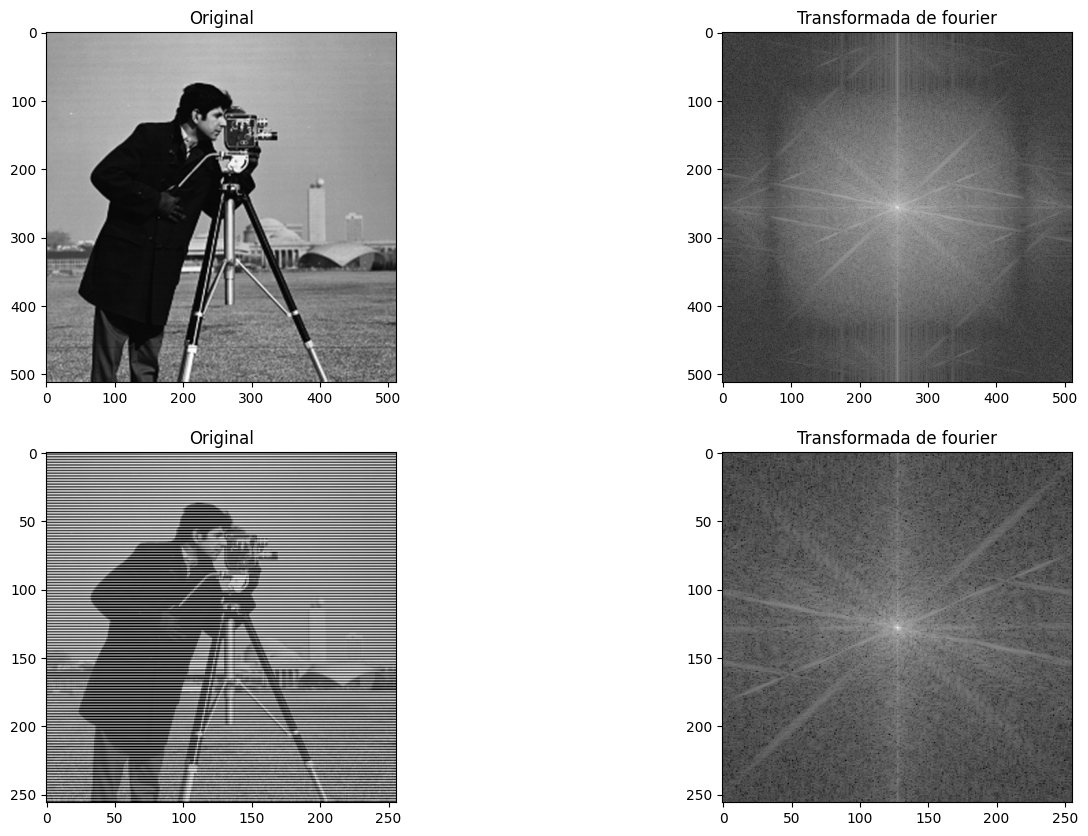

In [535]:
fourier = {
    name: {
        "tft": apply_fourier_transform(img)[1],
        "spectrum": apply_fourier_transform(img)[0]
    } for name, img in imgs.items()
}
# Mostrar imagem resultante
fig, ax = plt.subplots(len(fourier), 2, figsize=(16, 10))
for _ax, name in zip(ax, fourier.keys()):
    _ax[0].imshow(imgs[name], cmap='gray')
    _ax[0].set_title('Original')
    _ax[1].imshow(fourier[name]["spectrum"].astype(float), cmap='gray')
    _ax[1].set_title('Transformada de fourier')
    #_ax[0].axis('off')
    #_ax[1].axis('off')
fig.savefig(path_assets / "atv02-q09-init.png", bbox_inches='tight', dpi=400)
plt.show()


## a) uma solução aplicada no domínio da frequência

In [ ]:
img = imgs["cameraman_pattern"]
rows, cols = img.shape
crow, ccol = rows // 2 , cols // 2  # centro da imagem

# Aplicar a Transformada de Fourier
dft = np.fft.fft2(img)
dft_shift = np.fft.fftshift(dft)

# Criar o filtro Gaussiano
sigmas = [10, 20, 40, 50, 100]

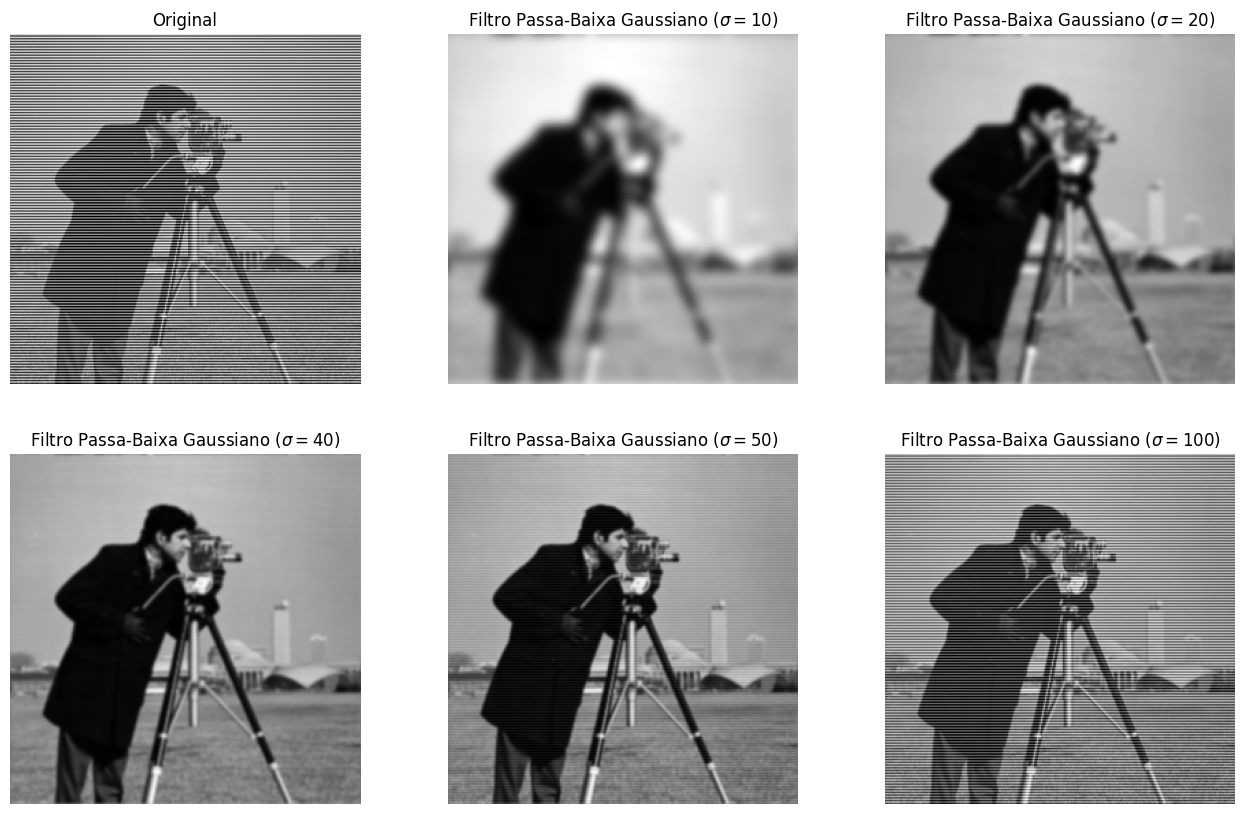

In [ ]:
fig, ax = plt.subplots(2, (len(sigmas) // 2) + 1, figsize=(16, 10))
ax = ax.flatten()
ax[0].imshow(img, cmap='gray')
ax[0].set_title('Original')
ax[0].axis('off')
for idx, sigma in enumerate(sigmas):
    # Calcula filtro passa-baixa gaussiano
    u = np.arange(-ccol, ccol)
    v = np.arange(-crow, crow)
    U, V = np.meshgrid(u, v)
    D = np.sqrt(U**2 + V**2)
    H = np.exp(-(D**2) / (2 * sigma**2))

    # Aplicar o filtro
    filtered_dft = dft_shift * H

    # Transformada Inversa
    f_ishift = np.fft.ifftshift(filtered_dft)
    img_back = np.fft.ifft2(f_ishift)
    img_back = np.abs(img_back)

    ax[idx + 1].imshow(img_back, cmap='gray')
    ax[idx + 1].set_title('Filtro Passa-Baixa Gaussiano ' + rf"($\sigma={sigma}$)")
    ax[idx + 1].axis('off')
fig.savefig(path_assets / "atv02-q09-a.png", bbox_inches='tight', dpi=400)
plt.show()

## b) uma solução aplicada no domínio espacial

Vamos aplicar um filtro box considerando uma vizinhança 2x2 e também um filtro gaussiano, com &sigma; = 1, para ver qual método consegue recuperar melhor a imagem original.

In [ ]:
filtered_img = {
    "Filtro box 2x2": cv2.blur(imgs["cameraman_pattern"], (2, 2)),  # aplicando um filtro box de dimensão 2x2
    "Filtro gaussiano": cv2.GaussianBlur(
        imgs["cameraman_pattern"],
        (0, 0),
        sigmaX=1,
        sigmaY=1
    ) # Aplicando um filtro gaussiano, com sigma = 1
}
# filtered_img = cv2.GaussianBlur(imgs["cameraman_pattern"], (3, 3), 1)
# filtered_img = box_blur_manual(imgs["cameraman_pattern"], ksize=(2, 2))

In [ ]:
fig, ax = plt.subplots(1, len(filtered_img.keys()) + 2, figsize=(20, 10))
ax[0].set_title('Original')
ax[0].imshow(imgs["cameraman_pattern"], cmap='gray')
ax[0].axis('off')

ax[1].set_title('Original (sem linhas)')
ax[1].imshow(imgs["cameraman"], cmap='gray')
ax[1].axis('off')

for _ax, (title, content) in zip(ax[2:], filtered_img.items()):
    _ax.imshow(content, cmap='gray')
    _ax.set_title(title)
    _ax.axis('off')
fig.tight_layout()
fig.savefig(path_assets / "atv02-q09-01.png", dpi=400, bbox_inches='tight')
plt.show()


### Conclusão

Ambos os filtros aplicados conseguiram sumir com as linhas existentes na imagem, porém ambos ainda sim causando um efeito de borramento, como era esperado de ambos. Para esse cenário especifico, o filtro box 2x2 conseguiu recuperar com mais detalhes, menos borrado quando comparado ao filtro gaussiano, não sendo tão fiel aos detalhes original.